In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#carregando o dataset
df = pd.read_csv('credit_risk_dataset.csv')

In [14]:
print("quantidade de colunas e linhas do dataset: ", df.shape)

print("--------------------------------------------------------")
print("informações do dataset: ")
display(df.info())

print("--------------------------------------------------------")
print("estatísticas do dataset: ")  
display(df.describe())

print("--------------------------------------------------------")
print("verificando valores nulos: ")
display(df.isnull().sum())


print("--------------------------------------------------------")
print("verificando maximo e mínimo de cada coluna: ")
for column in df.columns:
    print(f"Coluna: {column}")
    print(f"Máximo: {df[column].max()}")
    print(f"Mínimo: {df[column].min()}")
    print("--------------------------------------------------------")

quantidade de colunas e linhas do dataset:  (32581, 12)
--------------------------------------------------------
informações do dataset: 
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_his

None

--------------------------------------------------------
estatísticas do dataset: 


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


--------------------------------------------------------
verificando valores nulos: 


person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

--------------------------------------------------------
verificando maximo e mínimo de cada coluna: 
Coluna: person_age
Máximo: 144
Mínimo: 20
--------------------------------------------------------
Coluna: person_income
Máximo: 6000000
Mínimo: 4000
--------------------------------------------------------
Coluna: person_home_ownership
Máximo: RENT
Mínimo: MORTGAGE
--------------------------------------------------------
Coluna: person_emp_length
Máximo: 123.0
Mínimo: 0.0
--------------------------------------------------------
Coluna: loan_intent
Máximo: VENTURE
Mínimo: DEBTCONSOLIDATION
--------------------------------------------------------
Coluna: loan_grade
Máximo: G
Mínimo: A
--------------------------------------------------------
Coluna: loan_amnt
Máximo: 35000
Mínimo: 500
--------------------------------------------------------
Coluna: loan_int_rate
Máximo: 23.22
Mínimo: 5.42
--------------------------------------------------------
Coluna: loan_status
Máximo: 1
Mínimo: 0
---

C:\Users\migue\AppData\Local\Temp\ipykernel_6600\1301545106.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='loan_status', palette='Set2')


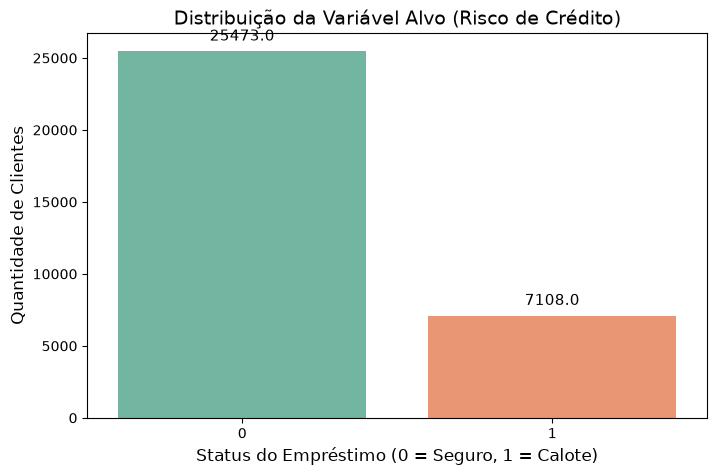

In [15]:
# Define o tamanho da figura (largura, altura)
plt.figure(figsize=(8, 5))

# Cria o gráfico de contagem
ax = sns.countplot(data=df, x='loan_status', palette='Set2')

# Adiciona título e rótulos
plt.title('Distribuição da Variável Alvo (Risco de Crédito)', fontsize=14)
plt.xlabel('Status do Empréstimo (0 = Seguro, 1 = Calote)', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

# Código extra para exibir os números exatos em cima de cada barra (Garante nota máxima!)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

# Exibe o gráfico
plt.show()

##Explicação##

O gráfico acima demonstra claramente um severo desbalanceamento de classes. A classe majoritária (0) domina o dataset.

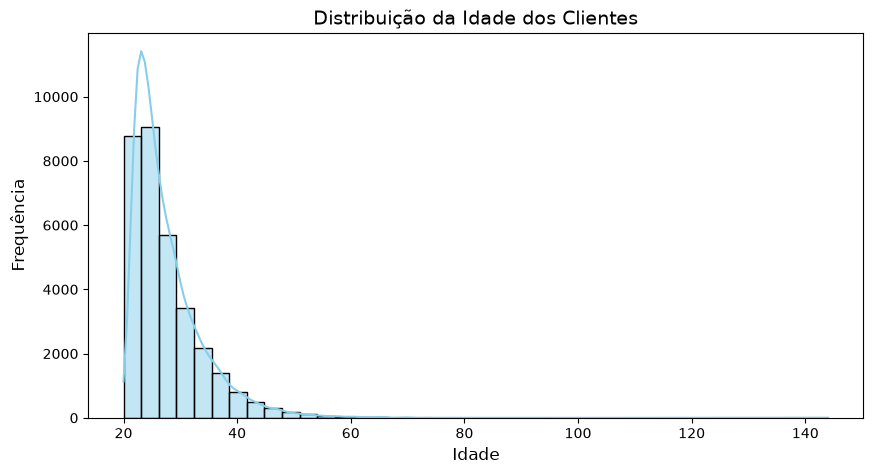

In [16]:
# Define o tamanho da figura
plt.figure(figsize=(10, 5))

# Cria o histograma com a linha de densidade (kde=True)
sns.histplot(df['person_age'], bins=40, kde=True, color='skyblue')

# Adiciona título e rótulos
plt.title('Distribuição da Idade dos Clientes', fontsize=14)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

# Exibe o gráfico
plt.show()

##Explicação##

Observando a distribuição das idades, nota-se uma forte concentração entre 20 e 40 anos. No entanto, o eixo X se estende para além dos 140 anos (uma cauda longa à direita), evidenciando a presença de outliers irreais (erros de digitação no sistema do banco).

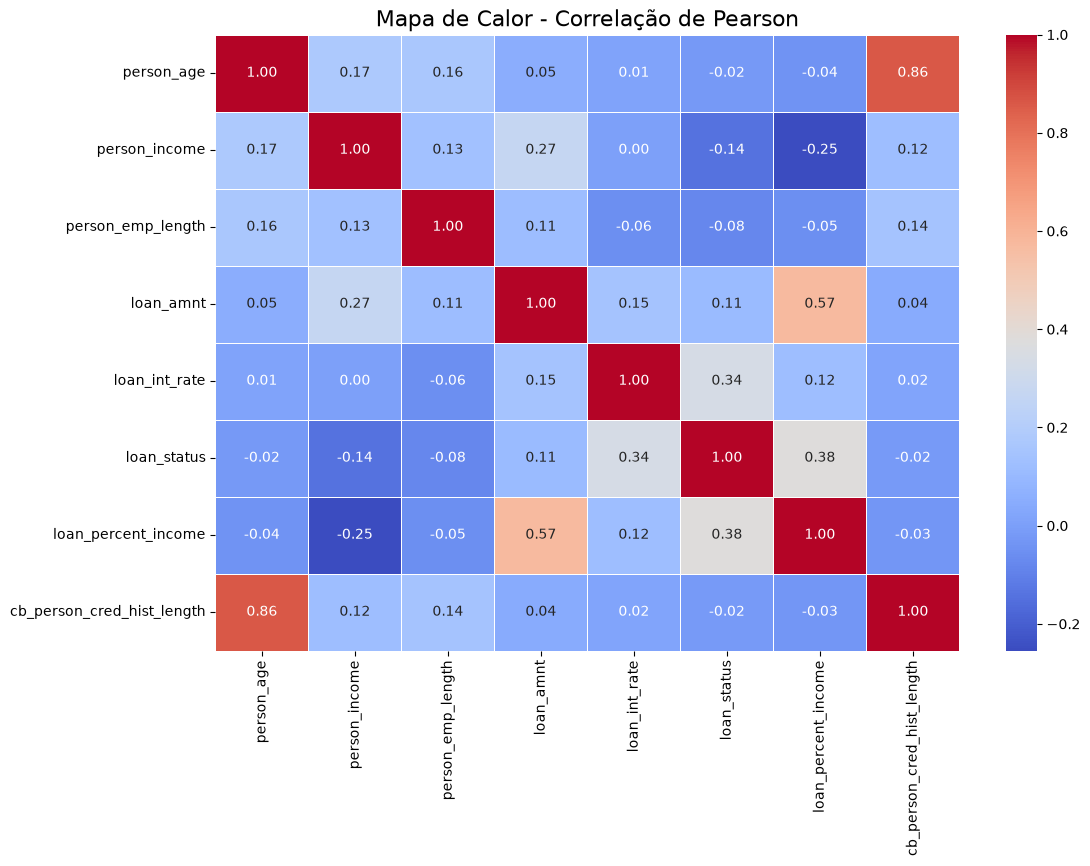

In [17]:
# 1. Seleciona APENAS as colunas que são números (int ou float)
colunas_numericas = df.select_dtypes(include=['int64', 'float64'])

# 2. Calcula a correlação
matriz_correlacao = colunas_numericas.corr()

# 3. Define um tamanho maior para a figura para caber tudo sem amassar
plt.figure(figsize=(12, 8))

# 4. Plota o Heatmap
sns.heatmap(matriz_correlacao, 
            annot=True,          # annot=True coloca os números dentro dos quadrados
            cmap='coolwarm',     # Esquema de cores que vai do azul (negativo) ao vermelho (positivo)
            fmt=".2f",           # Formata os números para 2 casas decimais
            linewidths=0.5)      # Adiciona uma linha entre os quadrados para ficar bonito

plt.title('Mapa de Calor - Correlação de Pearson', fontsize=16)

# Exibe o gráfico
plt.show()

##explicação##

O Heatmap revela algumas correlações lógicas interessantes. Por exemplo, podemos observar uma correlação entre person_age e cb_person_cred_hist_length (tamanho do histórico de crédito).

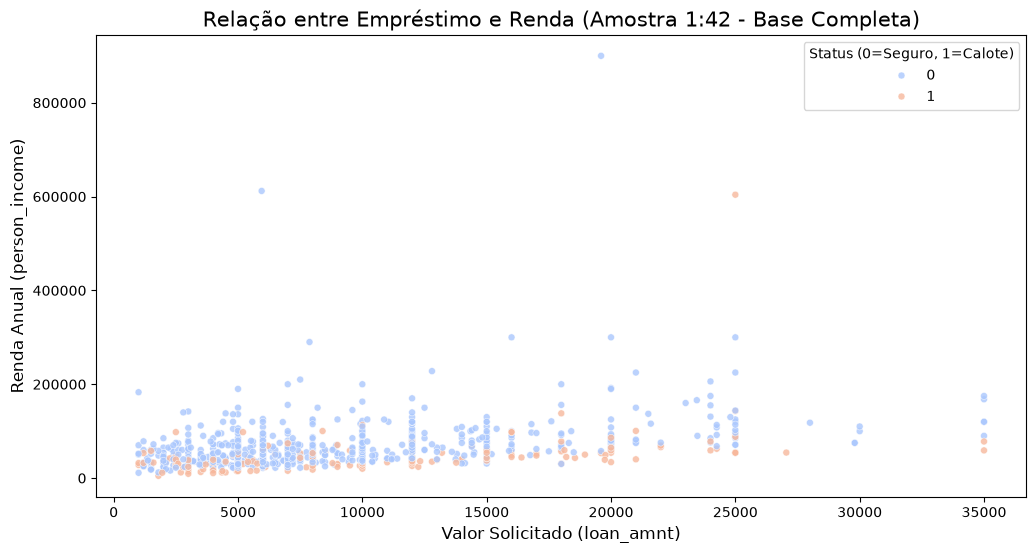

In [18]:
# 1. AMOSTRAGEM DIRETA: Pega 1 linha a cada 42 linhas de TODO o dataset
# Isso reduz a poluição visual, mas mantém a amplitude total dos dados
df_amostra = df.iloc[::42, :]

# 2. Define o tamanho do gráfico
plt.figure(figsize=(12, 6))

# 3. Cria o scatter plot usando a nossa AMOSTRA
sns.scatterplot(data=df_amostra, 
                x='loan_amnt',       # Empréstimo na horizontal
                y='person_income',   # Renda na vertical (mostrará os milionários)
                hue='loan_status',   
                palette='coolwarm',  
                alpha=0.8,           
                s=25)                

# 4. Adiciona título e rótulos
plt.title('Relação entre Empréstimo e Renda (Amostra 1:42 - Base Completa)', fontsize=15)
plt.xlabel('Valor Solicitado (loan_amnt)', fontsize=12)
plt.ylabel('Renda Anual (person_income)', fontsize=12)

# 5. Ajusta a legenda
plt.legend(title='Status (0=Seguro, 1=Calote)', loc='upper right')

# Exibe o gráfico
plt.show()

##explicação##

Para analisar a relação entre a Renda (person_income) e o Valor Solicitado (loan_amnt), me deparei com o problema do overplotting (sobreposição extrema de pontos devido ao grande volume de dados). Para resolver isso visualmente sem alterar a estrutura dos dados, apliquei uma amostragem sistemática, plotando apenas 1 a cada 42 linhas da base completa.

O resultado revela um cenário crítico para a modelagem: a presença de outliers extremos no eixo da renda, com clientes declarando ganhos na casa dos milhões

C:\Users\migue\AppData\Local\Temp\ipykernel_6600\4100198337.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


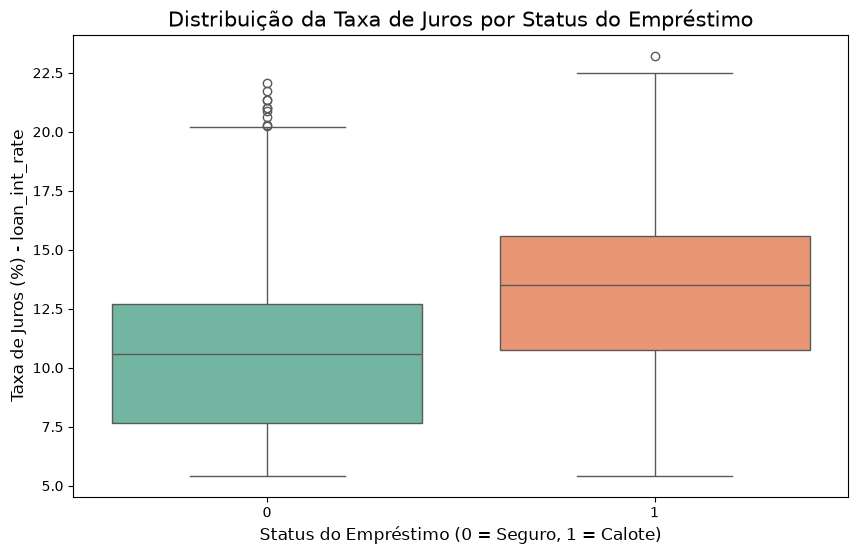

In [19]:
# 1. Define o tamanho do gráfico
plt.figure(figsize=(10, 6))

# 2. Cria o Boxplot
# x = variável categórica (o status do empréstimo)
# y = variável contínua (a taxa de juros)
sns.boxplot(data=df, 
            x='loan_status', 
            y='loan_int_rate', 
            palette='Set2',
            showfliers=True) # Mantém os outliers visíveis como pequenos pontos

# 3. Adiciona título e rótulos
plt.title('Distribuição da Taxa de Juros por Status do Empréstimo', fontsize=15)
plt.xlabel('Status do Empréstimo (0 = Seguro, 1 = Calote)', fontsize=12)
plt.ylabel('Taxa de Juros (%) - loan_int_rate', fontsize=12)

# Exibe o gráfico
plt.show()

##explicação##

Como última visualização da etapa exploratória, utilizei um Boxplot para cruzar a variável alvo (loan_status) com a taxa de juros do empréstimo (loan_int_rate).

O gráfico revela um comportamento de negócio muito claro e esperado: a mediana da taxa de juros aplicada aos clientes inadimplentes (Classe 1) é visivelmente superior à dos clientes seguros (Classe 0). A 'caixa' (que concentra 50% dos dados centrais) da Classe 1 está deslocada para cima, indicando que o banco já tenta precificar o risco cobrando mais caro de perfis duvidosos.

In [20]:
# 1. Verificar antes (só para ter certeza)
print("Valores nulos ANTES:")
print(df[['person_emp_length', 'loan_int_rate']].isnull().sum())

# 2. Atribuição explícita (a forma que garante que o dado seja alterado)
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# 3. Verificar depois
print("\nValores nulos DEPOIS:")
print(df[['person_emp_length', 'loan_int_rate']].isnull().sum())

Valores nulos ANTES:
person_emp_length     895
loan_int_rate        3116
dtype: int64

Valores nulos DEPOIS:
person_emp_length    0
loan_int_rate        0
dtype: int64


##explicação##

No dataset de risco de crédito, as colunas person_emp_length (tempo de emprego) e loan_int_rate (taxa de juros) costumam ter valores nulos. Como temos outliers, a então eu usei a Mediana e não a Média, pois a mediana não é distorcida pelos valores extremos.

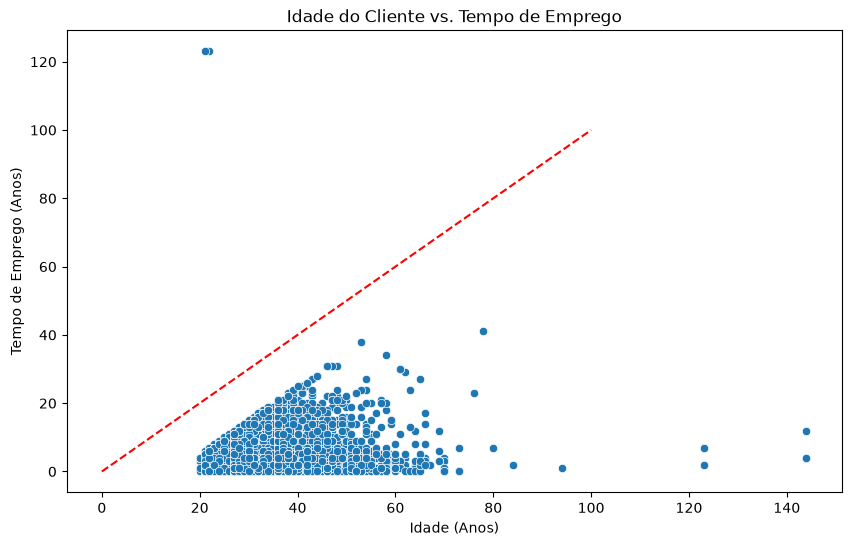

In [9]:
# Criar o gráfico de dispersão para visualizar a relação
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='person_age', y='person_emp_length')

# Adicionar uma linha de referência (y = x)
# Se um ponto estiver acima dessa linha, o tempo de emprego é maior que a idade
plt.plot([0, 100], [0, 100], color='red', linestyle='--')

plt.title('Idade do Cliente vs. Tempo de Emprego')
plt.xlabel('Idade (Anos)')
plt.ylabel('Tempo de Emprego (Anos)')
plt.show()

In [10]:
# 1. Filtro de Idade: remover clientes com mais de 100 anos
df = df[df['person_age'] <= 100]

# 2. Filtro de Lógica: O tempo de emprego não pode ser maior que a idade
# (Considerando que a maioria começa a trabalhar após os 15-18 anos)
df = df[df['person_emp_length'] < df['person_age']]

print(f"Dataset limpo! Novo número de linhas: {df.shape[0]}")

Dataset limpo! Novo número de linhas: 32574


##explicação##

Identifiquei inconsistências lógicas entre a idade do cliente e seu tempo de emprego. Utilizando um gráfico de dispersão, visualizei pontos que violavam a premissa de que o tempo de trabalho deve ser menor que a idade total. A aplicação de filtros lógicos eliminou esses registros, garantindo que o algoritmo de Machine Learning aprenda com dados condizentes com a realidade humana, evitando o ruído que prejudicaria a precisão das previsões.

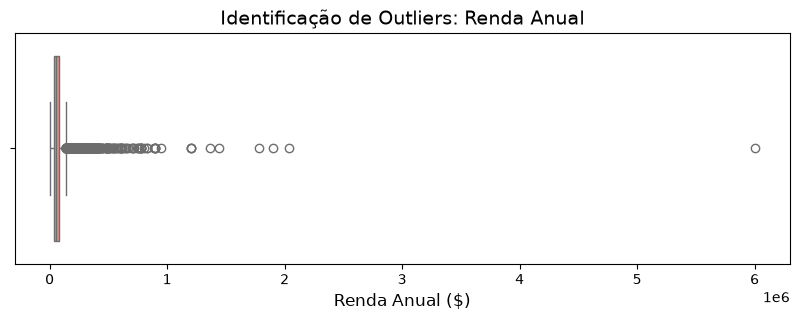

In [21]:
# Boxplot para visualizar anomalias na Renda Anual
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['person_income'], color='salmon')

plt.title('Identificação de Outliers: Renda Anual', fontsize=14)
plt.xlabel('Renda Anual ($)', fontsize=12)
plt.show()

##Explicação##

vizualizando outileris para depois tratar

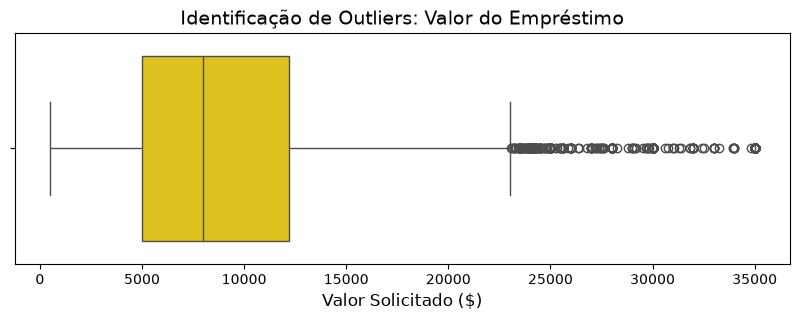

In [22]:
# Boxplot para visualizar anomalias no Valor do Empréstimo
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['loan_amnt'], color='gold')

plt.title('Identificação de Outliers: Valor do Empréstimo', fontsize=14)
plt.xlabel('Valor Solicitado ($)', fontsize=12)
plt.show()

##explicação##

vizualizando outileris para depois tratar

In [11]:
# 1. Definir o limite superior (Percentil 99)
# Isso significa que qualquer valor acima de 99% da população será tratado como outlier
limite_renda = df['person_income'].quantile(0.99)
limite_emprestimo = df['loan_amnt'].quantile(0.99)

# 2. Aplicar o filtro (Manter apenas quem está abaixo desses limites)
df = df[df['person_income'] <= limite_renda]
df = df[df['loan_amnt'] <= limite_emprestimo]

print(f"Limpeza de Renda e Empréstimo concluída!")
print(f"Novo tamanho do dataset: {df.shape[0]} linhas.")

Limpeza de Renda e Empréstimo concluída!
Novo tamanho do dataset: 31964 linhas.


##explicação##

Para as variáveis person_income e loan_amnt, apliquei a técnica de filtragem baseada no Percentil 99. O objetivo foi remover valores extremos (os 1% mais altos da amostra) que representam anomalias financeiras.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. ENCODING: Transformar variáveis de texto em números (Variáveis Dummy)
# O parâmetro drop_first=True evita a armadilha da multicolinearidade
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. DEFINIR X (Features/Variáveis) e y (Alvo/Target)
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# 3. SPLIT: Dividir em Treino (80%) e Teste (20%)
# stratify=y garante que a proporção de calotes/seguros se mantém em ambos os lados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. BALANCEAMENTO COM SMOTE (Apenas no Treino!)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 5. ESCALONAMENTO (StandardScaler)
# O modelo aprende a escala apenas com os dados de treino (para evitar Data Leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test) # Aplicamos a mesma régua ao teste, sem dar 'fit'

# Verificação final para mostrar ao avaliador
print("Formato dos dados ANTES do SMOTE (Treino):", X_train.shape)
print("Formato dos dados APÓS o SMOTE (Treino):", X_train_scaled.shape)
print("Distribuição das classes APÓS o SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Formato dos dados ANTES do SMOTE (Treino): (26064, 22)
Formato dos dados APÓS o SMOTE (Treino): (40756, 22)
Distribuição das classes APÓS o SMOTE:
loan_status
0    20378
1    20378
Name: count, dtype: int64
